In [1]:
cd C:\R_projects\mothz\detectron2\custom_training

C:\R_projects\mothz\detectron2\custom_training


In [2]:
import torch, detectron2, cv2
!nvcc --version
print("\nTorch CUDA version:", torch.version.cuda)
print("\nTorch version:", torch.__version__)
print("\ndetectron2:", detectron2.__version__)
print("\ncv2 version:",cv2.__version__)


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Sep__8_19:56:38_Pacific_Daylight_Time_2023
Cuda compilation tools, release 12.3, V12.3.52
Build cuda_12.3.r12.3/compiler.33281558_0

Torch CUDA version: 12.1

Torch version: 2.1.1

detectron2: 0.6

cv2 version: 4.11.0


In [3]:
print("Python version: ")
!python --version

Python version: 
Python 3.8.20


In [4]:
# Some basic setup:
# Setup detectron2 logger
from detectron2.utils.logger import setup_logger
setup_logger()
import numpy as np
import os, json, cv2, random
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import ColorMode,GenericMask,Visualizer
from detectron2.structures.keypoints import heatmaps_to_keypoints
from matplotlib import pyplot as plt
import glob
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    LVISEvaluator,
    PascalVOCDetectionEvaluator,
    SemSegEvaluator,
    DatasetEvaluator,
    inference_on_dataset,
    print_csv_format,
    verify_results,
)

In [5]:
# Register datasets and populate metadata
register_coco_instances("mothz_kp_train", {}, ".\keypoint\coco_kp_train.json", "C:\R_projects\mothz\coco-annotator\datasets\mothz_sample1")
register_coco_instances("mothz_kp_test", {}, ".\keypoint\coco_kp_test.json", "C:\R_projects\mothz\coco-annotator\datasets\mothz_sample1")
register_coco_instances("mothz_kp_val", {}, ".\keypoint\coco_kp_val.json", "C:\R_projects\mothz\coco-annotator\datasets\mothz_sample1")

In [6]:
things = ["forewing"] 
things_color = [(255, 0, 0)]
keypoint_names = ["inner", "outer"]
keypoint_map = []

MetadataCatalog.get("mothz_kp_train").set(thing_classes=things)
MetadataCatalog.get("mothz_kp_train").set(thing_colors=things_color)
MetadataCatalog.get("mothz_kp_train").set(keypoint_names=keypoint_names)
MetadataCatalog.get("mothz_kp_train").set(keypoint_flip_map=keypoint_map)

MetadataCatalog.get("mothz_kp_test").set(thing_classes=things)
MetadataCatalog.get("mothz_kp_test").set(thing_colors=things_color)
MetadataCatalog.get("mothz_kp_test").set(keypoint_names=keypoint_names)
MetadataCatalog.get("mothz_kp_test").set(keypoint_flip_map=keypoint_map)

MetadataCatalog.get("mothz_kp_val").set(thing_classes=things)
MetadataCatalog.get("mothz_kp_val").set(thing_colors=things_color)
MetadataCatalog.get("mothz_kp_val").set(keypoint_names=keypoint_names)
MetadataCatalog.get("mothz_kp_val").set(keypoint_flip_map=keypoint_map)

namespace(name='mothz_kp_val',
          json_file='.\\keypoint\\coco_kp_val.json',
          image_root='C:\\R_projects\\mothz\\coco-annotator\\datasets\\mothz_sample1',
          evaluator_type='coco',
          thing_classes=['forewing'],
          thing_colors=[(255, 0, 0)],
          keypoint_names=['inner', 'outer'],
          keypoint_flip_map=[])

In [7]:
from detectron2.custom.misc import *

In [8]:
# Set model configs
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("mothz_kp_train",)
cfg.DATASETS.TEST = ("mothz_kp_val", ) # Called test in detectron2, but is actually the validation data
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.DATALOADER.NUM_WORKERS = 2
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False 
cfg.TEST.EVAL_PERIOD = 0 # Turn off COCO evluator. 
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.0001  
cfg.SOLVER.MAX_ITER = 2500    
cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
cfg.SOLVER.WARMUP_ITERS = 200
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1 # Change for the number of classes
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.03 # Set to lower?
cfg.TEST.DETECTIONS_PER_IMAGE = 2 # Set higher to allow filtering by class later
cfg.SOLVER.CHECKPOINT_PERIOD = 200
cfg.MODEL.ROI_KEYPOINT_HEAD.NUM_KEYPOINTS = 2
cfg.TEST.KEYPOINT_OKS_SIGMAS = [0.1, 0.1]
cfg.INPUT.RANDOM_FLIP = "horizontal"
cfg.MODEL.MASK_ON = True
cfg.MODEL.KEYPOINT_ON = True # Keypoint detection for multiple thing classes not supported by detectron2
cfg.MODEL.ROI_KEYPOINT_HEAD.LOSS_WEIGHT = 5
cfg.MODEL.ROI_KEYPOINT_HEAD.NORMALIZE_LOSS_BY_VISIBLE_KEYPOINTS = False
cfg.OUTPUT_DIR = "./keypoint/model_v1"
#cfg.MODEL.BACKBONE.FREEZE_AT = 0
cfg.INPUT.MAX_SIZE_TEST = 2000
cfg.INPUT.MAX_SIZE_TRAIN = 2000
cfg.INPUT.MIN_SIZE_TEST = 2000
cfg.INPUT.MIN_SIZE_TRAIN = 2000

# cfg.MODEL.RPN.PRE_NMS_TOPK_TRAIN = 5000
#cfg.MODEL.RPN.PRE_NMS_TOPK_TEST = 3000
#cfg.MODEL.RPN.POST_NMS_TOPK_TRAIN = 2500
#cfg.MODEL.RPN.POST_NMS_TOPK_TEST = 2000
cfg.MODEL.RPN.NMS_THRESH = 0.9


os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [9]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: False
  NUM_WORKERS: 2
  REPEAT_SQRT: True
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('mothz_kp_val',)
  TRAIN: ('mothz_kp_train',)
FLOAT32_PRECISION: 
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 2000
  MAX_SIZE_TRAIN: 2000
  MIN_SIZE_TEST: 2000
  MIN_SIZE_TRAIN: 2000
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 2
    NAME: build_resnet_fpn_backbone
  DEVICE: cuda
  FPN:
    FUSE_TYPE: sum
    IN_FEATU

In [10]:
# Train model
trainer = CustomTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[02/06 22:38:12 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[02/06 22:38:13 d2.engine.train_loop]: Starting training from iteration 0


C:\Users\vsbpa\.conda\envs\mothz\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[02/06 22:38:55 d2.utils.events]:  eta: 0:57:58  iter: 19  total_loss: 9.9  loss_cls: 0.7585  loss_box_reg: 0.1439  loss_mask: 0.6983  loss_keypoint: 8.276  loss_rpn_cls: 0.0417  loss_rpn_loc: 0.009347    time: 1.3520  last_time: 1.3809  data_time: 0.5853  last_data_time: 0.4425   lr: 9.4413e-06  max_mem: 6265M
[02/06 22:39:30 d2.utils.events]:  eta: 0:57:33  iter: 39  total_loss: 8.144  loss_cls: 0.4944  loss_box_reg: 0.1064  loss_mask: 0.6728  loss_keypoint: 6.923  loss_rpn_cls: 0.0583  loss_rpn_loc: 0.009813    time: 1.3588  last_time: 1.5411  data_time: 0.4776  last_data_time: 0.6918   lr: 1.9274e-05  max_mem: 6266M
[02/06 22:39:56 d2.utils.events]:  eta: 0:56:14  iter: 59  total_loss: 10.74  loss_cls: 0.3094  loss_box_reg: 0.2775  loss_mask: 0.6163  loss_keypoint: 9.481  loss_rpn_cls: 0.03329  loss_rpn_loc: 0.008261    time: 1.3458  last_time: 1.4405  data_time: 0.4494  last_data_time: 0.4870   lr: 2.9107e-05  max_mem: 6266M
[02/06 22:40:24 d2.utils.events]:  eta: 0:56:20  iter: 7

In [11]:
# Look at model performance over iterations
%load_ext tensorboard
#%reload_ext tensorboard
%tensorboard --logdir "C:/R_projects/mothz/detectron2/custom_training/keypoint/model_v1"

### Go to directroy to delete temp file if TensorBoard fails to launch
# !del /S C:\Users\vsbpa\AppData\Local\Temp\.tensorboard-info

In [12]:
# Load fitted model as predictor
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_0001999.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.1  # set to 0.3 for now, but actually filtered to 0.7 in R
predictor = DefaultPredictor(cfg)

[02/06 23:49:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./keypoint/model_v1\model_0001999.pth ...


In [13]:
def draw_kp_mask(instances, Visualizer, radius = 20): 
    kp_l = instances.pred_keypoints.tolist()
    mask_l = np.asarray(instances.pred_masks)
    for i in range(len(kp_l)):
        try: out = Visualizer.draw_circle(kp_l[i][0][:2:], "green", radius = radius)
        except: print("inner point not detected") 
        try: out = Visualizer.draw_circle(kp_l[i][1][:2:], "red", radius = radius)
        except: print("outer point not detected") 
        try: out = Visualizer.draw_soft_mask(mask_l[i,:,:], "blue",alpha = 0.3)
        except: print("mask not detected") 
    return out
        
    

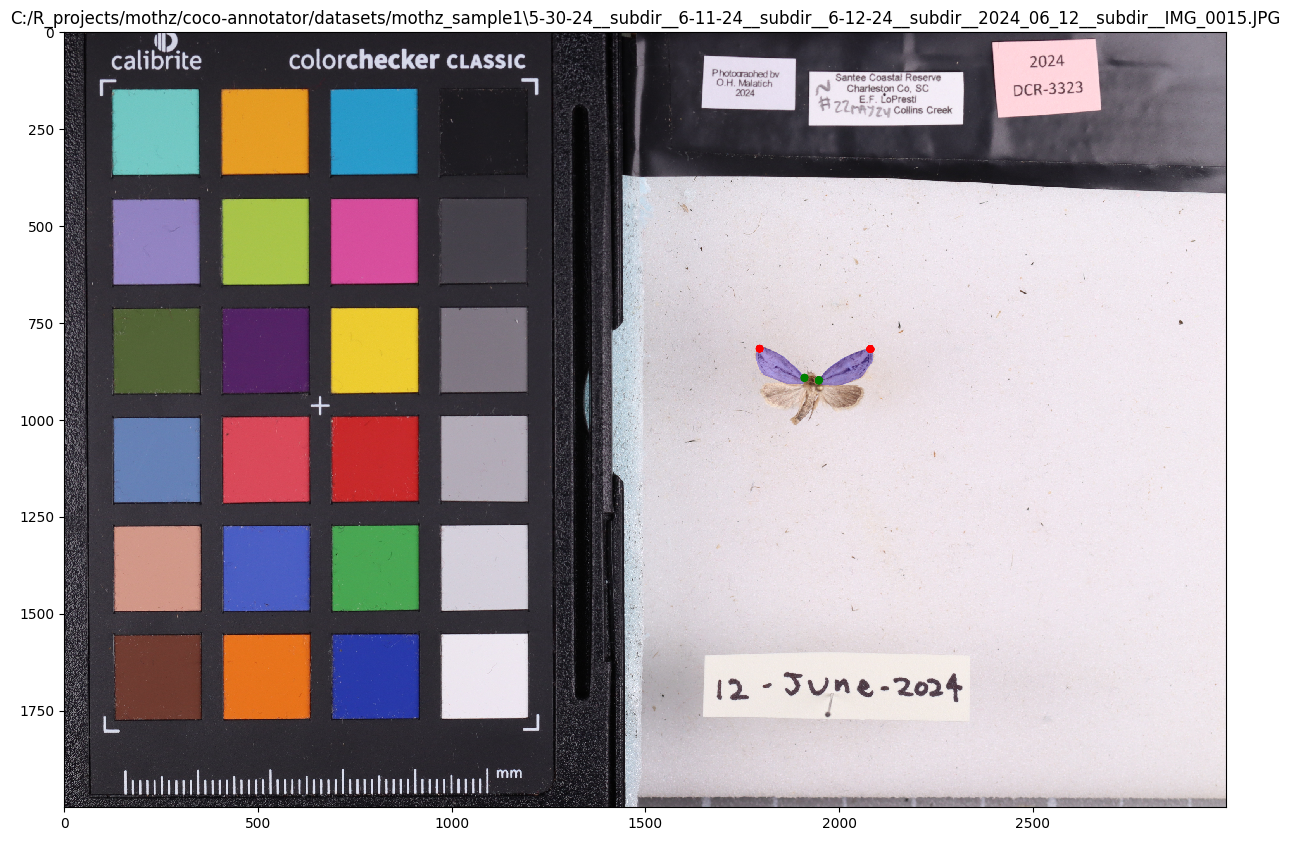

In [15]:
%matplotlib inline 

f = glob.glob("C:/R_projects/mothz/coco-annotator/datasets/mothz_sample1/*.JPG")
fi = random.choice(f)
#fi = f[0]
im = cv2.imread(fi)
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v = Visualizer(im[:, :, 0:3][:,:,::-1],
                   metadata=MetadataCatalog.get("mothz_kp_train"), 
                   scale=0.5, 
               instance_mode=ColorMode.IMAGE_BW
)
outputs = filter_instance_by_classes(outputs, "mothz_kp_test",[2]) # max detection: ['forewing']
#out = v.draw_instance_predictions(outputs, )
out = draw_kp_mask(outputs, v)

plt.figure(figsize = (15,15))
plt.imshow(out.get_image()[:,:,0:3], interpolation='nearest')
plt.title(fi)
plt.show()

In [ ]:
# For writing predictions
import csv
from datetime import datetime

# Function for writing csv
def write_csv(path, df):
    keys = df[0].keys()
    with open(path, "w", newline = "") as output_file: 
        dict_writer = csv.DictWriter(output_file, keys)
        dict_writer.writeheader()
        dict_writer.writerows(df)

def mask2polygon(mask, epsilon_wt = 0.01): 
  cont, _ = cv2.findContours(mask.astype('uint8'),cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE) 
  # format contour list as COCO
  polygon = []
  for contour in cont:
      epsilon = epsilon_wt * cv2.arcLength(contour, True)  # You can adjust epsilon based on your requirements
      approx = cv2.approxPolyDP(contour, epsilon, True)
      contour = np.flip(approx, axis=1)
      segmentation = contour.ravel().tolist()
      polygon.append(segmentation)
                    
  return polygon

def gather_image_meta(fi, instances, inference_info): 
    data = {}
    data["file_name"] = fi
    data["image_size"] = list(instances.image_size)
    data["inference_info"] = inference_info
    return data

def gather_instance_pred(fi, instances, meta): 
    dataset = []
    pred_classes = instances.pred_classes.tolist()
    classes_label = MetadataCatalog.get(meta).get("thing_classes")
    pred_class_score = instances.scores.tolist()
    pred_keypoints = instances.pred_keypoints.tolist()
    pred_bbox = instances.pred_boxes.tensor.tolist()
    pred_masks = instances.pred_masks.numpy()
    
    for i in range(len(instances)):
        data = {}
        data["file_name"] = fi
        data["thing_class"] = classes_label[pred_classes[i]]
        data["score"] = pred_class_score[i]
        data["keypoints"] = np.array(pred_keypoints[i]).ravel().tolist()
        data["bbox"] = pred_bbox[i]
        data["polygon"] = mask2polygon(pred_masks[i], 0.0001)
        dataset.append(data)
        
    return dataset


# For performing model inference on all images in a subdirectory corresponding to the supplied rep_ID in a root directory
def img_inference(predictor, root_path, inference_info, meta):
    meta_data_out = []
    instance_data_out = []
    f = glob.glob(os.path.join(root_path,"*.JPG"))
    tot = len(f)
    for i in range(tot):
        print(f"{i+1} of {tot}", end = "\r")
        fi = f[i]
        inst = predictor(cv2.imread(fi))
        inst = filter_instance_by_classes(inst, meta, [2])
        meta_data = gather_image_meta(fi, inst, inference_info)
        instance_data = gather_instance_pred(fi, inst, meta)
        meta_data_out.append(meta_data)
        instance_data_out = instance_data_out + instance_data
    
    return meta_data_out, instance_data_out

# Wrapper for writing model inference on all images in a subdirectory of the root directory 
def write_img_inference(predictor, write_path, name, read_path, model_ver, meta):
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    inference_info = model_ver + "__" + now
    df_meta, df_instance = img_inference(predictor, read_path, inference_info, meta)
    write_csv(os.path.join(write_path, name + "_inference_keypoint.csv"), df_instance)
    write_csv(os.path.join(write_path, name + "_image_meta_keypoint.csv"), df_meta)
    

In [ ]:
# Perform inference on the training dataset, saving both groundtruths and predictions
write_img_inference(
    predictor, 
    write_path = "C:/R_projects/mothz/",
    name = "test_auto_annotation",
    read_path = "C:/R_projects/mothz/coco-annotator/datasets/mothz_sample1/", 
    model_ver = "modelv0.1",
    meta = "mothz_kp_train"
    )

In [ ]:
a,b = img_inference(predictor,  "C:/R_projects/mothz/test/", "", "mothz_kp_train")